In [1]:
# Prepare Data First

In [1]:
import pandas as pd
import numpy as np

In [4]:
endurance_race_1_path = "barber-motorsports-park/barber/23_AnalysisEnduranceWithSections_Race 1_Anonymized.CSV"
endurance_race_2_path = "barber-motorsports-park/barber/23_AnalysisEnduranceWithSections_Race 2_Anonymized.CSV"

In [29]:
endurance_race_1 = pd.read_csv(endurance_race_1_path, sep =';')
endurance_race_2 = pd.read_csv(endurance_race_2_path, sep =';')

endurance_race_1['meta_session'] = 'R1'
endurance_race_2['meta_session'] = 'R2'

endurance = pd.concat([endurance_race_1, endurance_race_2])


In [ ]:
def prepare_endurance(df):
    df.columns=df.columns.str.strip()
    df.columns = df.columns.str.lower()
    df.rename(columns={'number': 'vehicle_number',"lap_number":"lap"}, inplace=True)
    df.dropna(axis=1, inplace=True)
    return df

In [38]:
endurance = prepare_endurance(endurance)
endurance.to_csv("simulation-data/endurance.csv")

In [ ]:
# BOUNDS

bounds1 = pd.read_csv('bounds1.csv')
bounds2 = pd.read_csv('bounds2.csv')
bounds = pd.concat([bounds1,bounds2])
bounds.to_csv("simulation-data/bounds.csv")

In [2]:
# Telemetry

telemetry_r1_parquet_path = "barber-motorsports-park/barber/R1_barber_telemetry_data.parquet"
telemetry_r2_parquet_path = "barber-motorsports-park/barber/R2_barber_telemetry_data.parquet"

tele_R1 = pd.read_parquet(telemetry_r1_parquet_path)
# tele_R2 = pd.read_parquet(telemetry_r2_parquet_path)

# df_tel_long = pd.concat([tele_R1, tele_R2])
# df_tel_long.dropna(axis=1, inplace=True)



In [17]:
df_tel_long.drop(columns=['meta_event', "meta_source","original_vehicle_id","vehicle_id","outing","timestamp"],inplace=True)

In [18]:
df_tel_long.to_parquet("simulation-data/telemetry.parquet")

In [1]:
df_tel_long.head(20)

NameError: name 'df_tel_long' is not defined

In [21]:
tele_R2.columns

Index(['expire_at', 'lap', 'meta_event', 'meta_session', 'meta_source',
       'meta_time', 'original_vehicle_id', 'outing', 'telemetry_name',
       'telemetry_value', 'timestamp', 'vehicle_id', 'vehicle_number'],
      dtype='object')

In [26]:
df_tel_long['telemetry_name'].value_counts()

telemetry_name
accx_can                  2427718
accy_can                  2427718
aps                       2427718
pbrake_r                  2427718
pbrake_f                  2427718
gear                      2427718
VBOX_Long_Minutes         2427718
VBOX_Lat_Min              2427718
Steering_Angle            2427718
Laptrigger_lapdist_dls     485572
nmot                       485572
speed                      485517
Name: count, dtype: int64

In [28]:
k = ["meta_session","vehicle_number","meta_time","telemetry_name"]
dups = (df_tel_long
        .assign(meta_time=pd.to_datetime(df_tel_long["meta_time"], utc=True),
                telemetry_value=pd.to_numeric(df_tel_long["telemetry_value"], errors="coerce"))
        .groupby(k)["telemetry_value"].agg(["count","nunique","min","max"]).reset_index()
        .query("count>1"))
print(dups.head())

  meta_session  vehicle_number                        meta_time  \
1           R1               0 2025-09-06 18:40:01.639000+00:00   
2           R1               0 2025-09-06 18:40:01.639000+00:00   
3           R1               0 2025-09-06 18:40:01.639000+00:00   
4           R1               0 2025-09-06 18:40:01.639000+00:00   
5           R1               0 2025-09-06 18:40:01.639000+00:00   

      telemetry_name  count  nunique        min        max  
1     Steering_Angle      7        1   3.900000   3.900000  
2       VBOX_Lat_Min      7        4  33.530472  33.530506  
3  VBOX_Long_Minutes      7        4 -86.620575 -86.620491  
4           accx_can      7        7  -0.040000   0.114000  
5           accy_can      7        6  -0.007000   0.015000  


In [31]:
def dedup_and_pivot(df_tel_long: pd.DataFrame) -> pd.DataFrame:
    df = df_tel_long.copy()
    df["meta_time"] = pd.to_datetime(df["meta_time"], utc=True, errors="coerce")
    df["telemetry_value"] = pd.to_numeric(df["telemetry_value"], errors="coerce")
    df["carId"] = df["vehicle_number"].astype(str)
    df["telemetry_name"] = df["telemetry_name"].astype("category")  # saves RAM

    # 1) Coalesce duplicates at SAME timestamp: mean within key
    agg = (df.groupby(["meta_session","carId","meta_time","telemetry_name"], observed=True)["telemetry_value"]
             .mean().reset_index())

    # 2) Pivot names → columns at timestamp level
    wide = (agg.pivot(index=["meta_session","carId","meta_time"],
                      columns="telemetry_name", values="telemetry_value")
               .reset_index().rename_axis(None, axis=1)
               .sort_values(["meta_session","carId","meta_time"]))
    return wide

,lap,meta_session,meta_time,telemetry_name,telemetry_value,vehicle_number
0,2,R1,2025-09-06T18:40:41.926Z,accx_can,0.346000,0
1,2,R1,2025-09-06T18:40:41.926Z,accy_can,-0.074000,0
2,2,R1,2025-09-06T18:40:41.926Z,aps,100.000000,0
3,2,R1,2025-09-06T18:40:41.926Z,pbrake_r,0.000000,0
4,2,R1,2025-09-06T18:40:41.926Z,pbrake_f,0.000000,0
...,...,...,...,...,...,...
11749599,28,R2,2025-09-07T15:48:40.654Z,gear,4.000000,5
11749600,28,R2,2025-09-07T15:48:40.654Z,VBOX_Long_Minutes,-86.619598,5
11749601,28,R2,2025-09-07T15:48:40.654Z,VBOX_Lat_Min,33.532635,5
11749602,28,R2,2025-09-07T15:48:40.654Z,Steering_Angle,0.100000,5


In [59]:
def bucket_coalesce_pivot(df_tel_long: pd.DataFrame, bin_ms: int = 10) -> pd.DataFrame:
    df = df_tel_long.copy()
    df["meta_time"] = pd.to_datetime(df["meta_time"], utc=True, errors="coerce")
    df["meta_time_bin"] = df["meta_time"].dt.round(f"{bin_ms}L")  # snap to 10ms grid
    df["telemetry_value"] = pd.to_numeric(df["telemetry_value"], errors="coerce")
    df["vehicle_number"] = df["vehicle_number"].astype(str)
    df["telemetry_name"] = df["telemetry_name"].astype("category")

    agg = (df.groupby(["meta_session","vehicle_number","meta_time_bin","telemetry_name"], observed=True)["telemetry_value"]
             .mean().reset_index())

    wide = (agg.pivot(index=["meta_session","vehicle_number","meta_time_bin"],
                      columns="telemetry_name", values="telemetry_value")
               .reset_index().rename(columns={"meta_time_bin":"meta_time"})
               .rename_axis(None, axis=1)
               .sort_values(["meta_session","vehicle_number","meta_time"]))
    return wide


In [60]:
test = bucket_coalesce_pivot(df_tel_long)

C:\Users\user\AppData\Local\Temp\ipykernel_69540\1922189342.py:4: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  df["meta_time_bin"] = df["meta_time"].dt.round(f"{bin_ms}L")  # snap to 10ms grid


In [61]:
test.to_parquet('simulation-data/telemetry_wide.parquet')

In [ ]:
# save as plot_track.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_track(df_tel_wide: pd.DataFrame,
               session: str,
               car_id: str,
               lat_col: str = "VBOX_Lat_Min",
               lon_col: str = "VBOX_Long_Minutes",
               downsample: int = 1):
    """
    Quick circuit sanity plot:
      - filters by meta_session & carId
      - sorts by meta_time
      - drops NaNs/out-of-range points
      - optional downsample for speed
      - plots lon vs lat with start/end markers
    """
    # --- select & sort ---
    d = df_tel_wide.copy()
    d["meta_session"] = d["meta_session"].astype(str)
    d["carId"] = d["carId"].astype(str)
    d["meta_time"] = pd.to_datetime(d["meta_time"], utc=True, errors="coerce")

    d = d[(d["meta_session"] == session) & (d["carId"] == car_id)].sort_values("meta_time")
    if d.empty:
        raise ValueError(f"No rows for session={session} carId={car_id}")

    # --- clean coords ---
    d = d.rename(columns={lat_col: "lat", lon_col: "lon"})
    d = d[["meta_time","lat","lon"]].dropna()

    # drop obviously bad lat/lon (valid ~[-90..90], [-180..180])
    d = d[(d["lat"].between(-90, 90)) & (d["lon"].between(-180, 180))]
    if d.empty:
        raise ValueError("All lat/lon rows were invalid/NaN after filtering.")

    # optional downsample
    if downsample > 1:
        d = d.iloc[::downsample].copy()

    # derive seconds since first sample (for colorbar)
    t0 = d["meta_time"].min()
    d["t_s"] = (d["meta_time"] - t0).dt.total_seconds()

    # --- print quick stats ---
    lat_min, lat_max = d["lat"].min(), d["lat"].max()
    lon_min, lon_max = d["lon"].min(), d["lon"].max()
    print(f"rows={len(d)}  time_span={d['t_s'].max():.1f}s  "
          f"lat[{lat_min:.6f},{lat_max:.6f}]  lon[{lon_min:.6f},{lon_max:.6f}]")

    # --- plot ---
    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(d["lon"], d["lat"], s=6, c=d["t_s"], cmap="viridis", alpha=0.9)
    ax.plot(d["lon"].values, d["lat"].values, lw=0.6, alpha=0.5)

    # mark start/end
    ax.scatter(d["lon"].iloc[0], d["lat"].iloc[0], s=60, marker="o", edgecolor="black", facecolor="lime", zorder=5, label="start")
    ax.scatter(d["lon"].iloc[-1], d["lat"].iloc[-1], s=60, marker="o", edgecolor="black", facecolor="red", zorder=5, label="end")

    ax.set_title(f"Track trace — session {session} / car {car_id}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, ls="--", alpha=0.3)
    cb = fig.colorbar(sc, ax=ax, label="t (s)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------- example usage ----------



rows=837  time_span=2696.2s  lat[33.529332,33.535885]  lon[-86.624298,-86.614540]


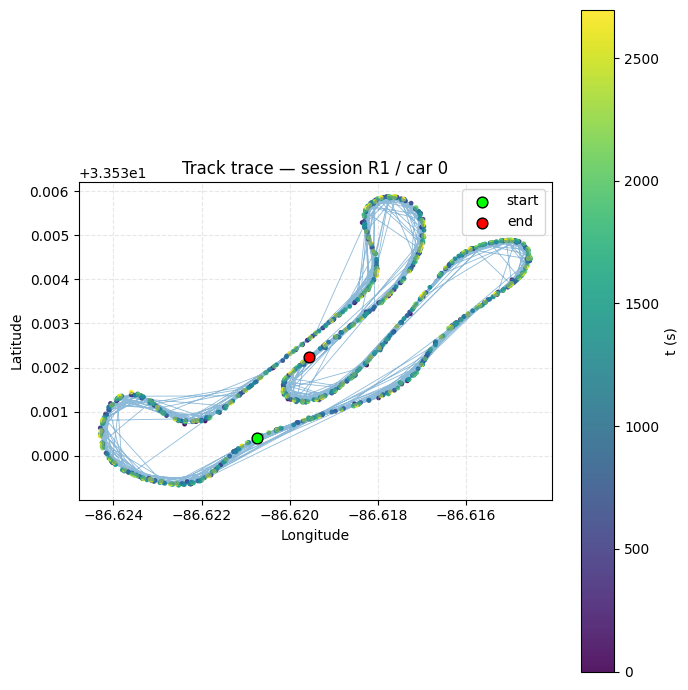

In [39]:
#df_tel_wide = pd.read_parquet("telemetry_timeline.parquet")  # or CSV
plot_track(test, session="R1", car_id="0", downsample=5)